---
### Rashed Ali Alkhathlan 
### 2240003321 | 7MA1
---


# N-Grams

It's a probabilistic model that's trained on a corpus of text. Such a model is useful in many NLP applications including speech recognition, machine translation and predictive text input. An N-gram model is built by counting how often word sequences occur in corpus text and then estimating the probabilities.

## Types of N-Grams

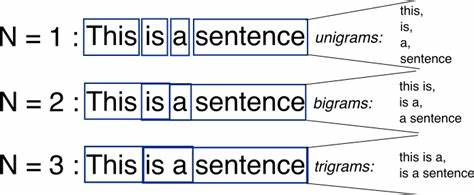

## Use-cases of N-Grams

- Auto completion of sentences
- Auto spell check
- Voice-based personal assistant bots

## Unigram

**Unigram** an n-gram consisting of a single item from a sequence.

- It is commonly used to calculate the probability of finding a word in an article.

$ count of (A) \div corpus length $

In [ ]:
from nltk.util import ngrams
from nltk.tokenize import word_tokenize

string = "moses supposes his toeses are roses but moses supposes erroneously"

unigrams = ngrams(word_tokenize(string), 1)

for item in unigrams:
    print(item)

('moses',)
('supposes',)
('his',)
('toeses',)
('are',)
('roses',)
('but',)
('moses',)
('supposes',)
('erroneously',)


### Calculating probabilities in unigram models

In [ ]:
### Calculate counts of each word

unique_string = set(word_tokenize(string))

words_frq = []
for uniques in unique_string:
    frq = string.count(uniques)
    words_frq.append((uniques, frq))

words_frq

[('toeses', 1),
 ('are', 1),
 ('roses', 1),
 ('his', 1),
 ('but', 1),
 ('erroneously', 1),
 ('supposes', 2),
 ('moses', 2)]

In [ ]:
### Calculate probabilities:

probab = []

for count in range(len(words_frq)):
    pro = words_frq[count][1]/len(string)
    probab.append(pro)

print('the probabilities are: ',probab)

the probabilities are:  [0.015151515151515152, 0.015151515151515152, 0.015151515151515152, 0.015151515151515152, 0.015151515151515152, 0.015151515151515152, 0.030303030303030304, 0.030303030303030304]


In [ ]:
probabilities = []
for i,j in zip(unique_string, probab):
    probabilities.append((i,j))
probabilities

[('toeses', 0.015151515151515152),
 ('are', 0.015151515151515152),
 ('roses', 0.015151515151515152),
 ('his', 0.015151515151515152),
 ('but', 0.015151515151515152),
 ('erroneously', 0.015151515151515152),
 ('supposes', 0.030303030303030304),
 ('moses', 0.030303030303030304)]

## Bigram

**Bigram** an n-gram consisting of two items from a sequence
- Two words that are used together to mean something specific

$ countof(A \ then \ B) \div countof(A) $

### Method 1

In [ ]:
import nltk as nl
from nltk.tokenize import word_tokenize

string = "moses supposes his toeses are roses but moses supposes erroneously"

bigrams = nl.bigrams(word_tokenize(string))
for i in bigrams:
    print(i)


('moses', 'supposes')
('supposes', 'his')
('his', 'toeses')
('toeses', 'are')
('are', 'roses')
('roses', 'but')
('but', 'moses')
('moses', 'supposes')
('supposes', 'erroneously')


### Method 2

In [ ]:
from nltk.util import ngrams
from nltk.tokenize import word_tokenize

string = "moses supposes his toeses are roses but moses supposes erroneously"

bigrams = ngrams(word_tokenize(string),2)

for i in bigrams:
    print(i)

('moses', 'supposes')
('supposes', 'his')
('his', 'toeses')
('toeses', 'are')
('are', 'roses')
('roses', 'but')
('but', 'moses')
('moses', 'supposes')
('supposes', 'erroneously')


# Trigram

**Trigram** an n-gram consisting of three items of a sequence
- Three words that are used together to mean something specific

### Method 1

In [ ]:
import nltk as nl
from nltk.tokenize import word_tokenize

string = "moses supposes his toeses are roses but moses supposes erroneously"

trigrams = nl.trigrams(word_tokenize(string))

for i in trigrams:
    print(i)


('moses', 'supposes', 'his')
('supposes', 'his', 'toeses')
('his', 'toeses', 'are')
('toeses', 'are', 'roses')
('are', 'roses', 'but')
('roses', 'but', 'moses')
('but', 'moses', 'supposes')
('moses', 'supposes', 'erroneously')


### Method 2

In [ ]:
from nltk.util import ngrams
from nltk.tokenize import word_tokenize

string = "moses supposes his toeses are roses but moses supposes erroneously"

trigrams = ngrams(word_tokenize(string),3)

for i in trigrams:
    print(i)


('moses', 'supposes', 'his')
('supposes', 'his', 'toeses')
('his', 'toeses', 'are')
('toeses', 'are', 'roses')
('are', 'roses', 'but')
('roses', 'but', 'moses')
('but', 'moses', 'supposes')
('moses', 'supposes', 'erroneously')


## What is padding in NLP?

padding is a technique used to ensure that all input sequences have the same length. This is necessary because neural networks require inputs that have the same shape and size. However, when we pre-process and use texts as inputs for our model, not all sentences have the same length. In other words, some sentences are longer or shorter than others. We need to have inputs with the same size, and this is where padding comes in 1.

Padding is a special form of masking where the masked steps are at the start or the end of a sequence. Padding comes from the need to encode sequence data into contiguous batches: in order to make all sequences in a batch fit a given standard length.
The padding is added before splitting the sentence.

n-1 padding is added.



In [ ]:
from nltk.util import ngrams
from nltk.tokenize import word_tokenize


string = "moses supposes his toeses are roses but moses supposes erroneously"

list(ngrams(word_tokenize(string), pad_left=True, left_pad_symbol="<s>",
                                pad_right=True, right_pad_symbol="</s>", n=2))

[('<s>', 'moses'),
 ('moses', 'supposes'),
 ('supposes', 'his'),
 ('his', 'toeses'),
 ('toeses', 'are'),
 ('are', 'roses'),
 ('roses', 'but'),
 ('but', 'moses'),
 ('moses', 'supposes'),
 ('supposes', 'erroneously'),
 ('erroneously', '</s>')]

Alternatively, We can get rid of the parameters by using
> pad_both_ends method in NLTK

**Note the n argument, that tells the function we need padding for bigrams.**

In [ ]:
from nltk.lm.preprocessing import pad_both_ends
from nltk.util import ngrams
from nltk.tokenize import word_tokenize

string = "moses supposes his toeses are roses but moses supposes erroneously"

list(ngrams(pad_both_ends(word_tokenize(string), n=2), n=2))


[('<s>', 'moses'),
 ('moses', 'supposes'),
 ('supposes', 'his'),
 ('his', 'toeses'),
 ('toeses', 'are'),
 ('are', 'roses'),
 ('roses', 'but'),
 ('but', 'moses'),
 ('moses', 'supposes'),
 ('supposes', 'erroneously'),
 ('erroneously', '</s>')]

### Training the Maximum Likelihood Model

Maximum likelihood estimation estimates the model parameters such that the probability is maximized.

- Get the requisite n_grams frequency counts from a corpus.

- Normalize them to a 0-1 range.

- Build the vocabulary: to create this vocabulary we need to pad our sentences (just like for counting ngrams) and then combine the sentences into one flat stream of words.


To do the above steps, we need to create and Ngram and add the padding then flatten the list. All these steps are requested for pre-processing to train the MLE model. However, we can use padded_everygram_pipeline() in NLTK to do all the steps in one call.


**References:**

https://www.nltk.org/api/nltk.lm.html

https://www.kaggle.com/code/alvations/n-gram-language-model-with-nltk

In [ ]:
from nltk.lm.preprocessing import padded_everygram_pipeline
from nltk.util import ngrams
from nltk.tokenize import word_tokenize
from nltk.lm import smoothing

string = "moses supposes his toeses are roses but moses supposes erroneously"

#Create Bigram Language Model
train, vocab = padded_everygram_pipeline(2, [word_tokenize(string)])

In [ ]:
from nltk.lm import MLE
lm = MLE(2)
lm.fit(train, vocab) #Train the Maximum Likelihood Model
print(lm.vocab)
print(len(lm.vocab))

<Vocabulary with cutoff=1 unk_label='<UNK>' and 11 items>
11


In [ ]:
lm.vocab.lookup(['moses','supposes'])

('moses', 'supposes')

In [ ]:
lm.vocab.lookup(['moses'])

('moses',)

### counts for unigrams and bigrams

In [ ]:
print(lm.counts['moses'])
# a then b
print(lm.counts[['moses']]['supposes'])

2
2


In [ ]:
print(lm.score('moses')) #Calculate Bigram Probabilities

0.16666666666666666


Here’s how you get the score for a word given some preceding context. For example we want to know what is the chance that “b” is preceded by “a”.

In [ ]:
# b then a
lm.score("supposes", ["moses"])

1.0

### Evaluating n_grams models using preplexity

**Preplexity** is the probability of the test set normalized by the number of words

In [ ]:
test = [('moses', 'supposes'), ('toeses','are')]
print(lm.perplexity(test))

1.0


## Task: Generating tweets using n_grams

In this Task, we will build a MLE model with n-gram to generate tweets.

The agenda is:
1. load the data:
https://www.kaggle.com/datasets/adizafar/large-random-tweets-from-pakistan

2. pre-processing the data:
*   Remove hashtags
*   Remove RT
*   Remove any website
*   Remove any mentions




3. build MLE model with n-gram
4. evaluate the model

before we start we need to install library to handle the emojis in tweets
> pip install emoji

# Part 1
# Task 1:

In [2]:
import pandas as pd
import re
import emoji
import random
import math
from collections import Counter

In [4]:
# 1. LOAD DATA

df = pd.read_csv("./data/tweets/tweets.csv", encoding="latin-1", low_memory=False)

# Change "text" if your tweet column has a different name
tweets = df["full_text"].dropna().astype(str)

In [14]:
# 2. PREPROCESSING

def clean_tweet(tweet):
    tweet = tweet.lower()

    # Remove RT
    tweet = re.sub(r'\brt\b', '', tweet)

    # Remove mentions
    tweet = re.sub(r'@\w+', '', tweet)

    # Remove hashtags
    tweet = re.sub(r'#\w+', '', tweet)

    # Remove websites
    tweet = re.sub(r'https?://\S+|www\.\S+', '', tweet)

    # Remove emojis
    tweet = emoji.replace_emoji(tweet, replace='')

    # Remove extra symbols, keep letters/numbers/spaces
    tweet = re.sub(r'[^a-z0-9\s]', ' ', tweet)

    # Remove extra spaces
    tweet = re.sub(r'\s+', ' ', tweet).strip()

    return tweet


tweets = tweets.apply(clean_tweet)
tweets = tweets[tweets != ""]

In [15]:
# 3. CREATE N-GRAM COUNTS

unigrams = Counter()
bigrams = Counter()
trigrams = Counter()

for tweet in tweets:
    words = tweet.split()

    # Add sentence start/end tokens
    tokens = ["<s>"] + words + ["</s>"]

    unigrams.update(tokens)

    bigrams.update(
        (tokens[i], tokens[i + 1])
        for i in range(len(tokens) - 1)
    )

    trigrams.update(
        (tokens[i], tokens[i + 1], tokens[i + 2])
        for i in range(len(tokens) - 2)
    )


In [16]:
# 4. REQUIRED COUNTS

print("Count of unigram 'pakistan':",
      unigrams["pakistan"])

print("Count of bigram 'is/pakistan':",
      bigrams[("is", "pakistan")])

print("Count of trigram 'a/pakistan is':",
      trigrams[("pakistan", "is", "a")])


Count of unigram 'pakistan': 14009
Count of bigram 'is/pakistan': 130
Count of trigram 'a/pakistan is': 70


In [17]:
# 5. REQUIRED PROBABILITIES

# P(pakistan | <s>)
p_pakistan_start = (
    bigrams[("<s>", "pakistan")] / unigrams["<s>"]
    if unigrams["<s>"] > 0 else 0
)

# P(is | pakistan)
p_is_pakistan = (
    bigrams[("pakistan", "is")] / unigrams["pakistan"]
    if unigrams["pakistan"] > 0 else 0
)

# P(a | pakistan is) -- trigram probability
p_a_pakistan_is = (
    trigrams[("pakistan", "is", "a")] /
    bigrams[("pakistan", "is")]
    if bigrams[("pakistan", "is")] > 0 else 0
)

print("\nP(pakistan | <s>):", p_pakistan_start)
print("P(is | pakistan):", p_is_pakistan)
print("P(a | pakistan is):", p_a_pakistan_is)


P(pakistan | <s>): 0.00932062826943868
P(is | pakistan): 0.04975372974516382
P(a | pakistan is): 0.10043041606886657


In [18]:
# 6. BIGRAM MLE MODEL

# Store possible next words for each word
next_words = {}

for (w1, w2), count in bigrams.items():
    if w1 not in next_words:
        next_words[w1] = []

    next_words[w1].extend([w2] * count)


In [19]:
# 7. GENERATE A TWEET

def generate_tweet(max_words=20):
    current = "<s>"
    generated = []

    for _ in range(max_words):

        if current not in next_words:
            break

        next_word = random.choice(next_words[current])

        if next_word == "</s>":
            break

        generated.append(next_word)
        current = next_word

    return " ".join(generated)


print("\nGenerated Tweets:")
for _ in range(5):
    print("-", generate_tweet())



Generated Tweets:
- bohat upar usme khush raho ameen coas regional challenges and development show this knesset member health researchers to set a
- 94 00 48 786 new match is ghea village ms always difficult let see babar xi babar azam
- k time to say he is really busy in psx building they replace it means travel plan for its basic
- o really made binance
- the current government


In [20]:
# 8. BIGRAM PERPLEXITY

log_probability = 0
N = 0

for tweet in tweets:
    tokens = ["<s>"] + tweet.split() + ["</s>"]

    for i in range(len(tokens) - 1):
        w1 = tokens[i]
        w2 = tokens[i + 1]

        probability = bigrams[(w1, w2)] / unigrams[w1]

        if probability > 0:
            log_probability += math.log(probability)
            N += 1

perplexity = math.exp(-log_probability / N)

print("\nPerplexity:", perplexity)


Perplexity: 68.60250375299391


# Part 2

# Task 1:

In [1]:
# 1. IMPORT LIBRARIES
import pandas as pd
import re
import html
import nltk
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
from nltk.corpus import stopwords
from nltk.tokenize import wordpunct_tokenize
from nltk.util import ngrams

try:
    stop_words = set(stopwords.words("english"))
except LookupError:
    nltk.download("stopwords", quiet=True, raise_on_error=True)
    stop_words = set(stopwords.words("english"))

# Support running from the repository root or the Lab3 folder.
lab3_dir = Path("Lab3") if Path("Lab3/Lab3.ipynb").exists() else Path(".")

In [2]:
# 2. LOAD DATA
reviews_df = pd.read_csv(lab3_dir / "data/imdb/IMDB Dataset.csv")
reviews_df["review"] = reviews_df["review"].fillna("").astype(str)
print("Total number of reviews:", len(reviews_df))
reviews_df.head()

Total number of reviews: 50000


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
# 3. PREPROCESS THE TEXT
def preprocess_text(text):
    text = html.unescape(str(text))
    text = re.sub(r"<[^>]+>", " ", text)
    # Replace punctuation with spaces so adjacent words do not merge.
    text = re.sub(r"[^a-zA-Z\s]", " ", text).lower()
    tokens = wordpunct_tokenize(text)
    return [word for word in tokens if word.isalpha() and word not in stop_words]

reviews_df["tokens"] = reviews_df["review"].apply(preprocess_text)
reviews_df["word_count"] = reviews_df["tokens"].apply(len)
reviews_df[["tokens", "word_count"]].head()

,tokens,word_count
0,"[one, reviewers, mentioned, watching, oz, epis...",162
1,"[wonderful, little, production, filming, techn...",86
2,"[thought, wonderful, way, spend, time, hot, su...",84
3,"[basically, family, little, boy, jake, thinks,...",64
4,"[petter, mattei, love, time, money, visually, ...",125


In [4]:
# 4. CALCULATE AND PRINT THE STATISTICS
has_good = reviews_df["tokens"].apply(lambda words: "good" in words)
has_bad = reviews_df["tokens"].apply(lambda words: "bad" in words)

print("Total number of reviews:", len(reviews_df))
print("Average word count per review (after preprocessing):",
      round(reviews_df["word_count"].mean(), 2))
print("Positive reviews (containing 'good'):", int(has_good.sum()))
print("Negative reviews (containing 'bad'):", int(has_bad.sum()))
print("Reviews containing both words:", int((has_good & has_bad).sum()))

Total number of reviews: 50000
Average word count per review (after preprocessing): 118.15
Positive reviews (containing 'good'): 19004
Negative reviews (containing 'bad'): 11788
Reviews containing both words: 5887


,Word,Frequency
0,movie,87972
1,film,79708
2,one,53603
3,like,40172
4,good,29753
5,time,25109
6,even,24872
7,would,24602
8,story,23121
9,really,23095


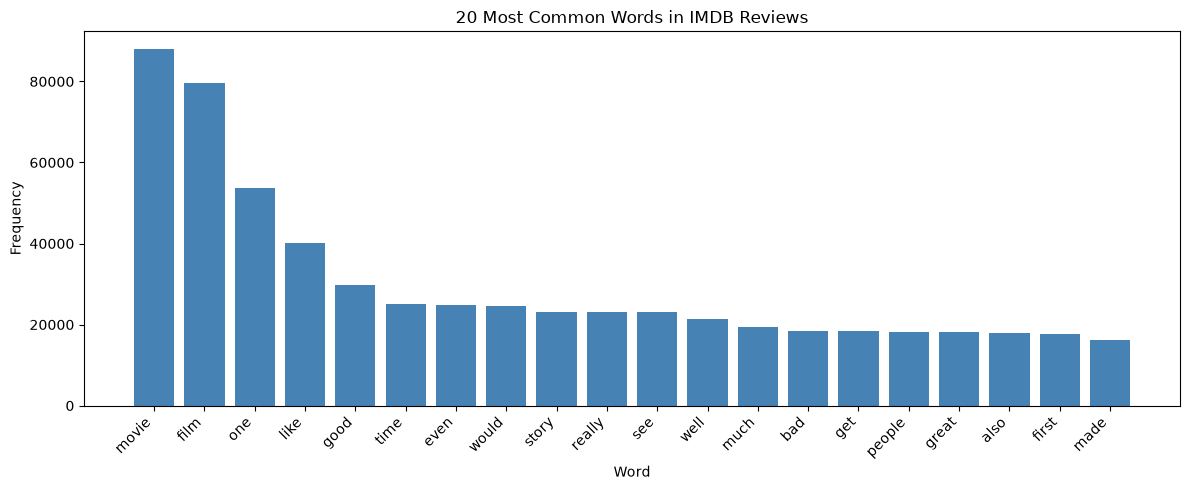

In [5]:
# 5. COUNT WORD FREQUENCIES
word_counts = Counter()
for tokens in reviews_df["tokens"]:
    word_counts.update(tokens)

common_words = pd.DataFrame(word_counts.most_common(20),
                            columns=["Word", "Frequency"])
display(common_words)

# 6. PLOT THE WORD FREQUENCY HISTOGRAM
plt.figure(figsize=(12, 5))
plt.bar(common_words["Word"], common_words["Frequency"], color="steelblue")
plt.title("20 Most Common Words in IMDB Reviews")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Task 2:

In [6]:
# 1. LOAD DATA
poems_df = pd.read_csv(lab3_dir / "data/poems/Poem_classification - train_data.csv")
print("Total rows loaded:", len(poems_df))
valid_poems = poems_df["Poem"].notna() & poems_df["Poem"].fillna("").str.strip().ne("")
print("Missing or blank poems removed:", int((~valid_poems).sum()))
poems_df = poems_df.loc[valid_poems].copy()
print("Poems used:", len(poems_df))
poems_df.head()

Total rows loaded: 841
Missing or blank poems removed: 4
Poems used: 837


,Genre,Poem
1,Music,In the thick brushthey spend the...
2,Music,Storms are generous. ...
3,Music,—After Ana Mendieta Did you carry around the ...
4,Music,for Aja Sherrard at 20The portent may itself ...
5,Music,"for Bob Marley, Bavaria, November 1980 Here i..."


In [7]:
# 2. PREPROCESS THE POEMS
poems_df["tokens"] = poems_df["Poem"].apply(preprocess_text)

# 3. GENERATE BIGRAMS
poems_df["bigrams"] = poems_df["tokens"].apply(lambda words: list(ngrams(words, 2)))
poems_df[["tokens", "bigrams"]].head()

,tokens,bigrams
1,"[thick, brushthey, spend, hottest, part, day, ...","[(thick, brushthey), (brushthey, spend), (spen..."
2,"[storms, generous, something, easy, surrender,...","[(storms, generous), (generous, something), (s..."
3,"[ana, mendieta, carry, around, matin, star, ho...","[(ana, mendieta), (mendieta, carry), (carry, a..."
4,"[aja, sherrard, portent, may, memory, wallace,...","[(aja, sherrard), (sherrard, portent), (porten..."
5,"[bob, marley, bavaria, november, brilliant, mo...","[(bob, marley), (marley, bavaria), (bavaria, n..."


In [8]:
# 4. CALCULATE BIGRAM FREQUENCIES
bigram_counts = Counter()
for poem_bigrams in poems_df["bigrams"]:
    bigram_counts.update(poem_bigrams)

# 5. DISPLAY THE TOP 10 BIGRAMS
top_bigrams = pd.DataFrame(bigram_counts.most_common(10),
                           columns=["Bigram", "Frequency"])
print("Total bigram occurrences:", sum(bigram_counts.values()))
print("Number of unique bigrams:", len(bigram_counts))
display(top_bigrams)

Total bigram occurrences: 21056
Number of unique bigrams: 19321


,Bigram,Frequency
0,"(let, us)",10
1,"(ah, yes)",8
2,"(every, day)",7
3,"(let, go)",6
4,"(first, time)",6
5,"(come, back)",6
6,"(let, say)",6
7,"(parking, lot)",6
8,"(give, us)",6
9,"(died, august)",5
